Using device: cpu
Loaded ONE long trajectory: T=152500, d=3
TTT | K=10 | Epoch 01 | train_MSE=15.626204 | val_MSE=14.640630 | best=14.640630
TTT | K=10 | Epoch 02 | train_MSE=7.126537 | val_MSE=7.801217 | best=7.801217
TTT | K=10 | Epoch 03 | train_MSE=3.710137 | val_MSE=3.990337 | best=3.990337
TTT | K=10 | Epoch 04 | train_MSE=1.829530 | val_MSE=1.879667 | best=1.879667
TTT | K=10 | Epoch 05 | train_MSE=0.831191 | val_MSE=0.810543 | best=0.810543
TTT | K=10 | Epoch 06 | train_MSE=0.347962 | val_MSE=0.329770 | best=0.329770
TTT | K=10 | Epoch 07 | train_MSE=0.145964 | val_MSE=0.143205 | best=0.143205
TTT | K=10 | Epoch 08 | train_MSE=0.065942 | val_MSE=0.065781 | best=0.065781
TTT | K=10 | Epoch 09 | train_MSE=0.034242 | val_MSE=0.036895 | best=0.036895
TTT | K=10 | Epoch 10 | train_MSE=0.021758 | val_MSE=0.024489 | best=0.024489
TTT | K=10 | Epoch 11 | train_MSE=0.015765 | val_MSE=0.018136 | best=0.018136
TTT | K=10 | Epoch 12 | train_MSE=0.012773 | val_MSE=0.015031 | best=0.015031
T

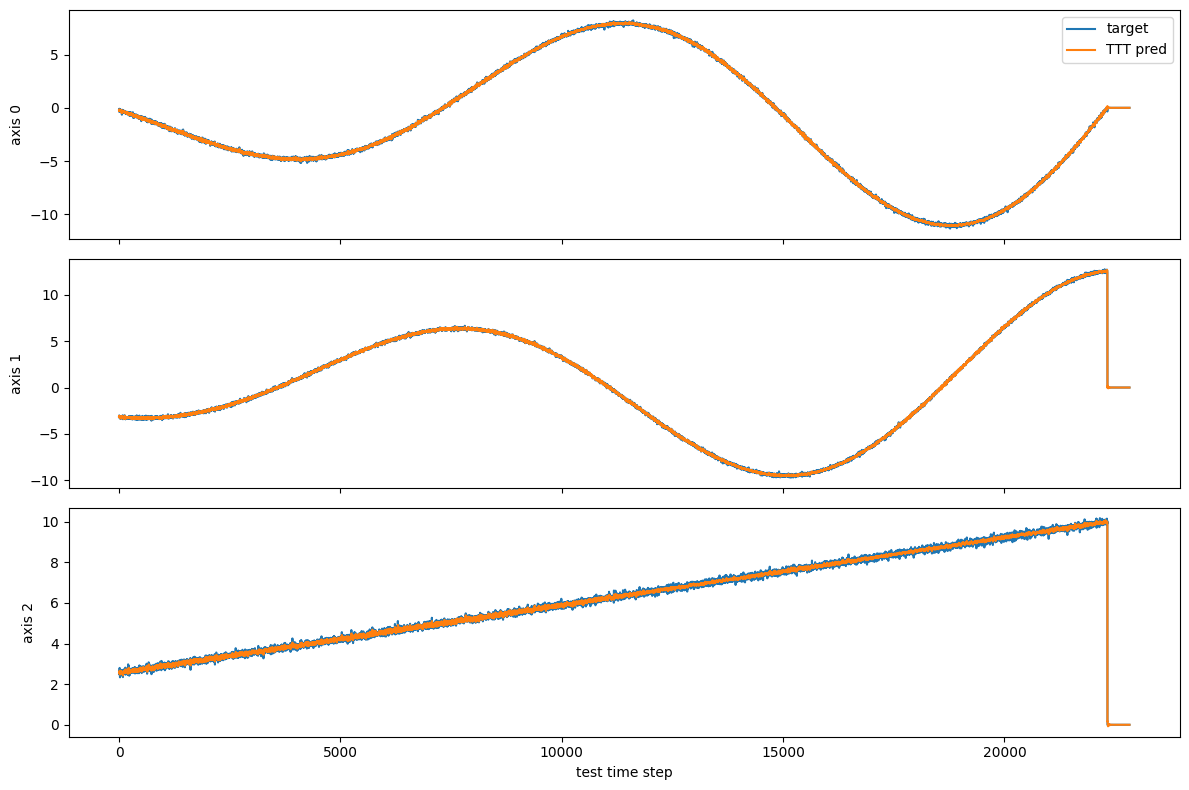

In [5]:
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

csv_path = '../../robotic_arm_dataset_multiple_trajectories.csv'
df = pd.read_csv(csv_path)
data = torch.from_numpy(df[['Axis_0_Angle', 'Axis_1_Angle', 'Axis_2_Angle']].values.astype(np.float32))
T, d = data.shape
print(f'Loaded ONE long trajectory: T={T}, d={d}')

def make_splits(series, train_frac=0.7, val_frac=0.15):
    T = len(series)
    train_end = int(train_frac * T)
    val_end = int((train_frac + val_frac) * T)
    train = series[:train_end]
    val = series[train_end:val_end]
    test = series[val_end:]
    return train, val, test

train_series, val_series, test_series = make_splits(data)


class SlidingWindowDataset(Dataset):
    def __init__(self, series, K):
        self.series = series
        self.K = K

    def __len__(self):
        return len(self.series) - self.K

    def __getitem__(self, idx):
        x = self.series[idx:idx + self.K]
        y = self.series[idx + self.K]
        return x, y


class RNNRegressor(nn.Module):
    def __init__(self, d_in, hidden_size):
        super().__init__()
        self.rnn = nn.GRU(d_in, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, d_in)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        n += batch_size
    return total_loss / n


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = criterion(pred, y)
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        n += batch_size
    return total_loss / n


import copy

def evaluate_with_ttt(base_model, test_series, K, device, adapt_lr=1e-4, adapt_steps=1):
    model = copy.deepcopy(base_model).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=adapt_lr)
    criterion = nn.MSELoss()
    model.train()
    T_test = len(test_series)
    preds = []
    targets = []
    total_loss = 0.0
    n = 0
    for start in range(T_test - K):
        window = test_series[start:start + K].unsqueeze(0).to(device)
        target = test_series[start + K].unsqueeze(0).to(device)
        for _ in range(adapt_steps):
            optimizer.zero_grad()
            pred = model(window)
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            pred = model(window)
            loss = criterion(pred, target)
        preds.append(pred.squeeze(0).cpu().numpy())
        targets.append(target.squeeze(0).cpu().numpy())
        total_loss += loss.item()
        n += 1
    preds = np.stack(preds)
    targets = np.stack(targets)
    mse = total_loss / n
    return preds, targets, mse


Ks = [10, 50, 100]
num_epochs = 20
batch_size = 256
criterion = nn.MSELoss()
results = {}

for K in Ks:
    train_ds = SlidingWindowDataset(train_series, K)
    val_ds = SlidingWindowDataset(val_series, K)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    base_test_ds = SlidingWindowDataset(test_series, K)
    base_test_loader = DataLoader(base_test_ds, batch_size=batch_size, shuffle=False)

    model = RNNRegressor(d_in=d, hidden_size=K).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    best_val = float('inf')
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = eval_epoch(model, val_loader, criterion, device)
        base_test_mse_epoch = eval_epoch(model, base_test_loader, criterion, device)
        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
        print(f'TTT | K={K} | Epoch {epoch:02d} | train_MSE={train_loss:.6f} | val_MSE={val_loss:.6f} | base_test_MSE={base_test_mse_epoch:.6f} | best_val_MSE={best_val:.6f}')

    model.load_state_dict(best_state)
    base_test_ds = SlidingWindowDataset(test_series, K)
    base_test_loader = DataLoader(base_test_ds, batch_size=batch_size, shuffle=False)
    base_test_mse = eval_epoch(model, base_test_loader, criterion, device)
    preds_ttt, targets_ttt, ttt_mse = evaluate_with_ttt(model, test_series, K, device, adapt_lr=1e-4, adapt_steps=1)
    results[K] = {
        'model': model,
        'base_test_mse': base_test_mse,
        'ttt_mse': ttt_mse,
        'preds_ttt': preds_ttt,
        'targets_ttt': targets_ttt,
    }
    print(f'K={K} | base test MSE={base_test_mse:.6f} | TTT test MSE={ttt_mse:.6f}')


K_plot = 50
preds = results[K_plot]['preds_ttt']
targets = results[K_plot]['targets_ttt']
t = np.arange(len(preds))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, targets[:, i], label='target')
    ax.plot(t, preds[:, i], label='TTT pred')
    ax.set_ylabel(f'axis {i}')
axes[-1].set_xlabel('test time step')
axes[0].legend()
plt.tight_layout()
plt.show()


TTT H-ablation | K=10 | H=1 | Epoch 01 | train_MSE=24.897777 | val_MSE=30.371584 | best=30.371584
TTT H-ablation | K=10 | H=1 | Epoch 02 | train_MSE=21.316351 | val_MSE=27.563447 | best=27.563447
TTT H-ablation | K=10 | H=1 | Epoch 03 | train_MSE=19.561794 | val_MSE=26.240794 | best=26.240794
TTT H-ablation | K=10 | H=1 | Epoch 04 | train_MSE=18.674800 | val_MSE=25.141367 | best=25.141367
TTT H-ablation | K=10 | H=1 | Epoch 05 | train_MSE=17.785349 | val_MSE=23.944045 | best=23.944045
TTT H-ablation | K=10 | H=1 | Epoch 06 | train_MSE=16.919779 | val_MSE=22.934122 | best=22.934122
TTT H-ablation | K=10 | H=1 | Epoch 07 | train_MSE=16.268849 | val_MSE=22.191898 | best=22.191898
TTT H-ablation | K=10 | H=1 | Epoch 08 | train_MSE=15.807587 | val_MSE=21.680622 | best=21.680622
TTT H-ablation | K=10 | H=1 | Epoch 09 | train_MSE=15.513458 | val_MSE=21.345662 | best=21.345662
TTT H-ablation | K=10 | H=1 | Epoch 10 | train_MSE=14.904452 | val_MSE=19.890743 | best=19.890743
TTT H-ablation | K=1

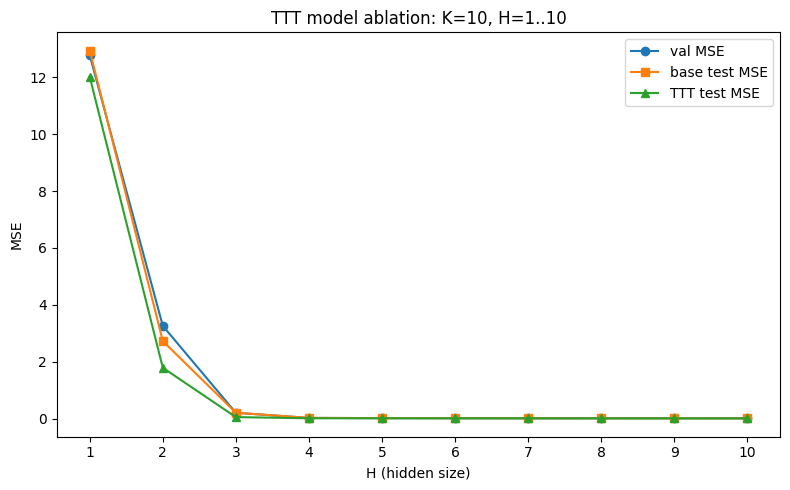

In [6]:
# H (hidden size) ablation study: fix K, vary H from 1 to 10 (same as RNN notebook)
K_ablation = 10
H_list = list(range(1, 11))
num_epochs_ablation = 20
batch_size_ablation = 256
criterion_ablation = nn.MSELoss()

ablation_val_mse = []
ablation_base_test_mse = []
ablation_ttt_test_mse = []

train_ds_h = SlidingWindowDataset(train_series, K_ablation)
val_ds_h = SlidingWindowDataset(val_series, K_ablation)
train_loader_h = DataLoader(train_ds_h, batch_size=batch_size_ablation, shuffle=True, drop_last=True)
val_loader_h = DataLoader(val_ds_h, batch_size=batch_size_ablation, shuffle=False)

for H in H_list:
    model_h = RNNRegressor(d_in=d, hidden_size=H).to(device)
    optimizer_h = torch.optim.Adam(model_h.parameters(), lr=1e-3)
    best_val = float('inf')
    best_state = None
    for epoch in range(1, num_epochs_ablation + 1):
        train_loss = train_one_epoch(model_h, train_loader_h, optimizer_h, criterion_ablation, device)
        val_loss = eval_epoch(model_h, val_loader_h, criterion_ablation, device)
        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model_h.state_dict())
        print(f'TTT H-ablation | K={K_ablation} | H={H} | Epoch {epoch:02d} | train_MSE={train_loss:.6f} | val_MSE={val_loss:.6f} | best={best_val:.6f}')
    model_h.load_state_dict(best_state)
    ablation_val_mse.append(best_val)
    base_test_loader_h = DataLoader(SlidingWindowDataset(test_series, K_ablation), batch_size=batch_size_ablation, shuffle=False)
    base_mse = eval_epoch(model_h, base_test_loader_h, criterion_ablation, device)
    _, _, ttt_mse = evaluate_with_ttt(model_h, test_series, K_ablation, device, adapt_lr=1e-4, adapt_steps=1)
    ablation_base_test_mse.append(base_mse)
    ablation_ttt_test_mse.append(ttt_mse)
    print(f'H={H} | val_MSE={best_val:.6f} | base test MSE={base_mse:.6f} | TTT test MSE={ttt_mse:.6f}')

# Plot H ablation: val MSE, base test MSE, TTT test MSE vs H
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(H_list, ablation_val_mse, 'o-', label='val MSE')
ax.plot(H_list, ablation_base_test_mse, 's-', label='base test MSE')
ax.plot(H_list, ablation_ttt_test_mse, '^-', label='TTT test MSE')
ax.set_xlabel('H (hidden size)')
ax.set_ylabel('MSE')
ax.set_xticks(H_list)
ax.legend()
ax.set_title(f'TTT model ablation: K={K_ablation}, H=1..10')
plt.tight_layout()
plt.show()

TTT H-ablation | K=50 | H=1 | Epoch 01 | train_MSE=20.922791 | val_MSE=26.422533 | best=26.422533
TTT H-ablation | K=50 | H=1 | Epoch 02 | train_MSE=18.123792 | val_MSE=24.134132 | best=24.134132
TTT H-ablation | K=50 | H=1 | Epoch 03 | train_MSE=16.412619 | val_MSE=22.214315 | best=22.214315
TTT H-ablation | K=50 | H=1 | Epoch 04 | train_MSE=15.018183 | val_MSE=20.582794 | best=20.582794
TTT H-ablation | K=50 | H=1 | Epoch 05 | train_MSE=13.881805 | val_MSE=19.160809 | best=19.160809
TTT H-ablation | K=50 | H=1 | Epoch 06 | train_MSE=12.933500 | val_MSE=17.934595 | best=17.934595
TTT H-ablation | K=50 | H=1 | Epoch 07 | train_MSE=12.163223 | val_MSE=16.895992 | best=16.895992
TTT H-ablation | K=50 | H=1 | Epoch 08 | train_MSE=11.529586 | val_MSE=16.005211 | best=16.005211
TTT H-ablation | K=50 | H=1 | Epoch 09 | train_MSE=11.009228 | val_MSE=15.246635 | best=15.246635
TTT H-ablation | K=50 | H=1 | Epoch 10 | train_MSE=10.576548 | val_MSE=14.603313 | best=14.603313
TTT H-ablation | K=5

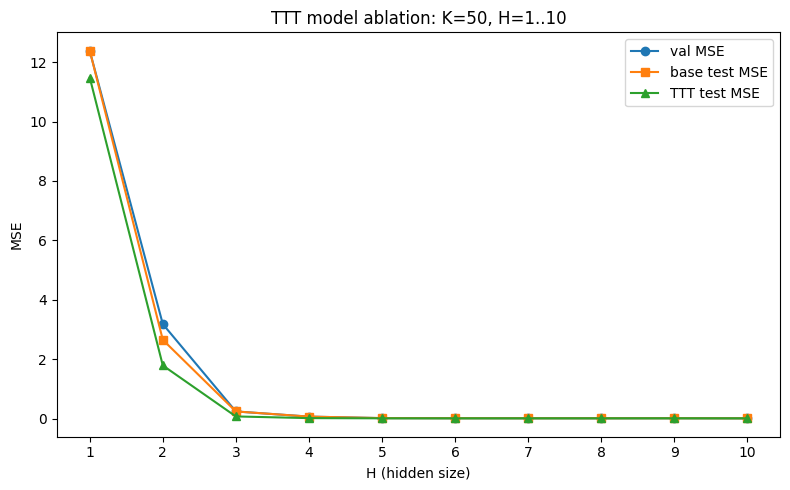

In [7]:
# H (hidden size) ablation study: fix K, vary H from 1 to 10 (same as RNN notebook)
K_ablation = 50
H_list = list(range(1, 11))
num_epochs_ablation = 20
batch_size_ablation = 256
criterion_ablation = nn.MSELoss()

ablation_val_mse = []
ablation_base_test_mse = []
ablation_ttt_test_mse = []

train_ds_h = SlidingWindowDataset(train_series, K_ablation)
val_ds_h = SlidingWindowDataset(val_series, K_ablation)
train_loader_h = DataLoader(train_ds_h, batch_size=batch_size_ablation, shuffle=True, drop_last=True)
val_loader_h = DataLoader(val_ds_h, batch_size=batch_size_ablation, shuffle=False)

for H in H_list:
    model_h = RNNRegressor(d_in=d, hidden_size=H).to(device)
    optimizer_h = torch.optim.Adam(model_h.parameters(), lr=1e-3)
    best_val = float('inf')
    best_state = None
    for epoch in range(1, num_epochs_ablation + 1):
        train_loss = train_one_epoch(model_h, train_loader_h, optimizer_h, criterion_ablation, device)
        val_loss = eval_epoch(model_h, val_loader_h, criterion_ablation, device)
        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model_h.state_dict())
        print(f'TTT H-ablation | K={K_ablation} | H={H} | Epoch {epoch:02d} | train_MSE={train_loss:.6f} | val_MSE={val_loss:.6f} | best={best_val:.6f}')
    model_h.load_state_dict(best_state)
    ablation_val_mse.append(best_val)
    base_test_loader_h = DataLoader(SlidingWindowDataset(test_series, K_ablation), batch_size=batch_size_ablation, shuffle=False)
    base_mse = eval_epoch(model_h, base_test_loader_h, criterion_ablation, device)
    _, _, ttt_mse = evaluate_with_ttt(model_h, test_series, K_ablation, device, adapt_lr=1e-4, adapt_steps=1)
    ablation_base_test_mse.append(base_mse)
    ablation_ttt_test_mse.append(ttt_mse)
    print(f'H={H} | val_MSE={best_val:.6f} | base test MSE={base_mse:.6f} | TTT test MSE={ttt_mse:.6f}')

# Plot H ablation: val MSE, base test MSE, TTT test MSE vs H
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(H_list, ablation_val_mse, 'o-', label='val MSE')
ax.plot(H_list, ablation_base_test_mse, 's-', label='base test MSE')
ax.plot(H_list, ablation_ttt_test_mse, '^-', label='TTT test MSE')
ax.set_xlabel('H (hidden size)')
ax.set_ylabel('MSE')
ax.set_xticks(H_list)
ax.legend()
ax.set_title(f'TTT model ablation: K={K_ablation}, H=1..10')
plt.tight_layout()
plt.show()

TTT H-ablation | K=100 | H=1 | Epoch 01 | train_MSE=24.641384 | val_MSE=30.483840 | best=30.483840
TTT H-ablation | K=100 | H=1 | Epoch 02 | train_MSE=21.957314 | val_MSE=28.053892 | best=28.053892
TTT H-ablation | K=100 | H=1 | Epoch 03 | train_MSE=19.968478 | val_MSE=25.998776 | best=25.998776
TTT H-ablation | K=100 | H=1 | Epoch 04 | train_MSE=18.283540 | val_MSE=24.151406 | best=24.151406
TTT H-ablation | K=100 | H=1 | Epoch 05 | train_MSE=16.840667 | val_MSE=22.509964 | best=22.509964
TTT H-ablation | K=100 | H=1 | Epoch 06 | train_MSE=15.643714 | val_MSE=21.103717 | best=21.103717
TTT H-ablation | K=100 | H=1 | Epoch 07 | train_MSE=14.678660 | val_MSE=19.912049 | best=19.912049
TTT H-ablation | K=100 | H=1 | Epoch 08 | train_MSE=13.897614 | val_MSE=18.899887 | best=18.899887
TTT H-ablation | K=100 | H=1 | Epoch 09 | train_MSE=13.259810 | val_MSE=18.045008 | best=18.045008
TTT H-ablation | K=100 | H=1 | Epoch 10 | train_MSE=12.741870 | val_MSE=17.334695 | best=17.334695
TTT H-abla

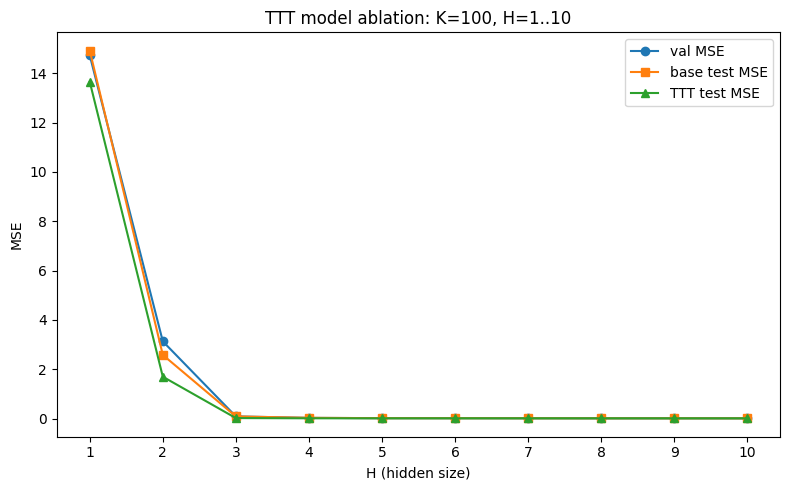

In [ ]:
# H (hidden size) ablation study: fix K, vary H from 1 to 10 (same as RNN notebook)
K_ablation = 100
H_list = list(range(1, 11))
num_epochs_ablation = 20
batch_size_ablation = 256
criterion_ablation = nn.MSELoss()

ablation_val_mse = []
ablation_base_test_mse = []
ablation_ttt_test_mse = []

train_ds_h = SlidingWindowDataset(train_series, K_ablation)
val_ds_h = SlidingWindowDataset(val_series, K_ablation)
train_loader_h = DataLoader(train_ds_h, batch_size=batch_size_ablation, shuffle=True, drop_last=True)
val_loader_h = DataLoader(val_ds_h, batch_size=batch_size_ablation, shuffle=False)

for H in H_list:
    model_h = RNNRegressor(d_in=d, hidden_size=H).to(device)
    optimizer_h = torch.optim.Adam(model_h.parameters(), lr=1e-3)
    best_val = float('inf')
    best_state = None
    for epoch in range(1, num_epochs_ablation + 1):
        train_loss = train_one_epoch(model_h, train_loader_h, optimizer_h, criterion_ablation, device)
        val_loss = eval_epoch(model_h, val_loader_h, criterion_ablation, device)
        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model_h.state_dict())
        print(f'TTT H-ablation | K={K_ablation} | H={H} | Epoch {epoch:02d} | train_MSE={train_loss:.6f} | val_MSE={val_loss:.6f} | best={best_val:.6f}')
    model_h.load_state_dict(best_state)
    ablation_val_mse.append(best_val)
    base_test_loader_h = DataLoader(SlidingWindowDataset(test_series, K_ablation), batch_size=batch_size_ablation, shuffle=False)
    base_mse = eval_epoch(model_h, base_test_loader_h, criterion_ablation, device)
    _, _, ttt_mse = evaluate_with_ttt(model_h, test_series, K_ablation, device, adapt_lr=1e-4, adapt_steps=1)
    ablation_base_test_mse.append(base_mse)
    ablation_ttt_test_mse.append(ttt_mse)
    print(f'H={H} | val_MSE={best_val:.6f} | base test MSE={base_mse:.6f} | TTT test MSE={ttt_mse:.6f}')

# Plot H ablation: val MSE, base test MSE, TTT test MSE vs H
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(H_list, ablation_val_mse, 'o-', label='val MSE')
ax.plot(H_list, ablation_base_test_mse, 's-', label='base test MSE')
ax.plot(H_list, ablation_ttt_test_mse, '^-', label='TTT test MSE')
ax.set_xlabel('H (hidden size)')
ax.set_ylabel('MSE')
ax.set_xticks(H_list)
ax.legend()
ax.set_title(f'TTT model ablation: K={K_ablation}, H=1..10')
plt.tight_layout()
plt.show()

Computing BASE error growth  (K=10)
[BASE] K=10, max_horizon=10, total_starts=10000
[BASE]   2000/10000 | avg_MSE=0.012001 | avg_MAE=0.082940
[BASE]   4000/10000 | avg_MSE=0.010495 | avg_MAE=0.077918
[BASE]   6000/10000 | avg_MSE=0.010528 | avg_MAE=0.078666
[BASE]   8000/10000 | avg_MSE=0.010654 | avg_MAE=0.079006
[BASE]  10000/10000 | avg_MSE=0.012072 | avg_MAE=0.083561
[BASE] done.

Computing TTT  error growth  (K=10)
[TTT] K=10, max_horizon=10, total_starts=10000, adapt_lr=0.0001, adapt_steps=1
[TTT]    500/10000 | avg_MSE=0.009146 | avg_MAE=0.072798
[TTT]   1000/10000 | avg_MSE=0.009279 | avg_MAE=0.073748
[TTT]   1500/10000 | avg_MSE=0.008936 | avg_MAE=0.072719
[TTT]   2000/10000 | avg_MSE=0.008752 | avg_MAE=0.071991
[TTT]   2500/10000 | avg_MSE=0.008617 | avg_MAE=0.071429
[TTT]   3000/10000 | avg_MSE=0.008527 | avg_MAE=0.070783
[TTT]   3500/10000 | avg_MSE=0.008382 | avg_MAE=0.070132
[TTT]   4000/10000 | avg_MSE=0.008242 | avg_MAE=0.069579
[TTT]   4500/10000 | avg_MSE=0.008361 | a

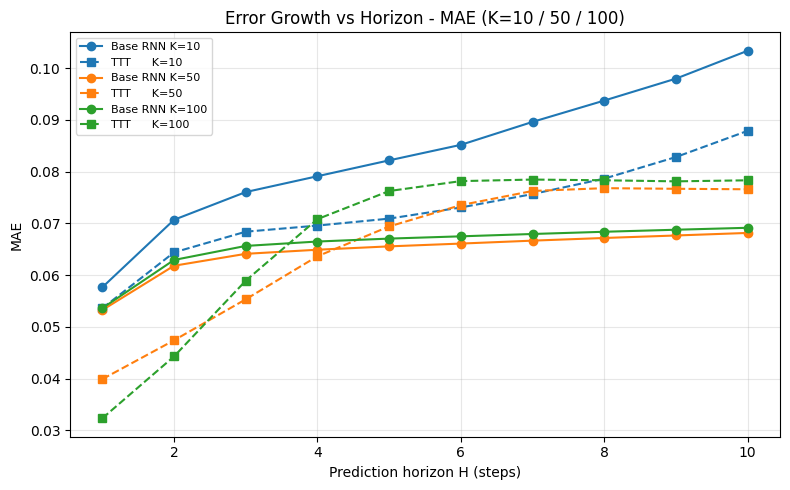

In [15]:
# Error Growth vs Horizon for TTT (prediction horizon H = multi-step, not hidden size)

import copy

def error_growth_base(model, test_series, K, max_horizon, device, log_every=2000, max_starts=10000):
    model.eval()
    T_test = len(test_series)
    errors_mse = np.zeros(max_horizon)
    errors_mae = np.zeros(max_horizon)
    counts = np.zeros(max_horizon)
    total = min(T_test - K - max_horizon, max_starts)
    print(f'[BASE] K={K}, max_horizon={max_horizon}, total_starts={total}')

    with torch.no_grad():
        for idx in range(total):
            window = test_series[idx:idx + K].unsqueeze(0).to(device)
            for h in range(1, max_horizon + 1):
                pred = model(window)
                target = test_series[idx + K + (h - 1)].unsqueeze(0).to(device)
                diff = pred - target
                errors_mse[h - 1] += (diff ** 2).mean().item()
                errors_mae[h - 1] += diff.abs().mean().item()
                counts[h - 1] += 1
                window = torch.cat([window[:, 1:, :], pred.unsqueeze(1)], dim=1)
            if (idx + 1) % log_every == 0 or (idx + 1) == total:
                cur_mse = (errors_mse / counts).mean()
                cur_mae = (errors_mae / counts).mean()
                print(f'[BASE] {idx+1:6d}/{total} | avg_MSE={cur_mse:.6f} | avg_MAE={cur_mae:.6f}')

    print('[BASE] done.')
    return errors_mse / counts, errors_mae / counts


def error_growth_ttt(base_model, test_series, K, max_horizon, device,
                     adapt_lr=1e-4, adapt_steps=1, log_every=500, max_starts=10000):
    T_test = len(test_series)
    errors_mse = np.zeros(max_horizon)
    errors_mae = np.zeros(max_horizon)
    counts = np.zeros(max_horizon)
    total = min(T_test - K - max_horizon, max_starts)
    print(f'[TTT] K={K}, max_horizon={max_horizon}, total_starts={total}, '
          f'adapt_lr={adapt_lr}, adapt_steps={adapt_steps}')

    for idx in range(total):
        model = copy.deepcopy(base_model).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=adapt_lr)
        criterion = nn.MSELoss()
        model.train()

        window = test_series[idx:idx + K].unsqueeze(0).to(device)

        for h in range(1, max_horizon + 1):
            target = test_series[idx + K + (h - 1)].unsqueeze(0).to(device)
            for _ in range(adapt_steps):
                optimizer.zero_grad()
                pred = model(window)
                loss = criterion(pred, target)
                loss.backward()
                optimizer.step()
            with torch.no_grad():
                pred = model(window)
                diff = pred - target
                errors_mse[h - 1] += (diff ** 2).mean().item()
                errors_mae[h - 1] += diff.abs().mean().item()
            counts[h - 1] += 1
            window = torch.cat([window[:, 1:, :], pred.unsqueeze(1)], dim=1)

        if (idx + 1) % log_every == 0 or (idx + 1) == total:
            cur_mse = (errors_mse / counts).mean()
            cur_mae = (errors_mae / counts).mean()
            print(f'[TTT] {idx+1:6d}/{total} | avg_MSE={cur_mse:.6f} | avg_MAE={cur_mae:.6f}')

    print('[TTT] done.')
    return errors_mse / counts, errors_mae / counts


# ---- run for K = 10, 50, 100 ----
max_horizon = 10
Ks_horizon = [10, 50, 100]
horizon_results = {}   # {K: {'base_mse', 'base_mae', 'ttt_mse', 'ttt_mae'}}

for K_horizon in Ks_horizon:
    base_model = results[K_horizon]['model']

    print('=' * 55)
    print(f'Computing BASE error growth  (K={K_horizon})')
    print('=' * 55)
    b_mse, b_mae = error_growth_base(
        base_model, test_series, K_horizon, max_horizon, device,
        log_every=2000, max_starts=10000)

    print()
    print('=' * 55)
    print(f'Computing TTT  error growth  (K={K_horizon})')
    print('=' * 55)
    t_mse, t_mae = error_growth_ttt(
        base_model, test_series, K_horizon, max_horizon, device,
        adapt_lr=1e-4, adapt_steps=1, log_every=500, max_starts=10000)

    horizon_results[K_horizon] = {
        'base_mse': b_mse, 'base_mae': b_mae,
        'ttt_mse': t_mse,  'ttt_mae': t_mae,
    }

    print()
    print(f'Per-horizon results (K={K_horizon}):')
    print(f'{"H":>3} | {"base_MSE":>12} {"base_MAE":>12} | {"TTT_MSE":>12} {"TTT_MAE":>12}')
    print('-' * 60)
    for h in range(1, max_horizon + 1):
        print(f'{h:3d} | {b_mse[h-1]:12.6f} {b_mae[h-1]:12.6f} | '
              f'{t_mse[h-1]:12.6f} {t_mae[h-1]:12.6f}')
    print()

# ---- final combined MAE plot (all K on one figure) ----
horizons = np.arange(1, max_horizon + 1)
colors = {10: 'tab:blue', 50: 'tab:orange', 100: 'tab:green'}

plt.figure(figsize=(8, 5))
for K_horizon in Ks_horizon:
    r = horizon_results[K_horizon]
    c = colors[K_horizon]
    plt.plot(horizons, r['base_mae'], 'o-',  color=c, label=f'Base RNN K={K_horizon}')
    plt.plot(horizons, r['ttt_mae'],  's--', color=c, label=f'TTT      K={K_horizon}')

plt.xlabel('Prediction horizon H (steps)')
plt.ylabel('MAE')
plt.title('Error Growth vs Horizon - MAE (K=10 / 50 / 100)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()